<h1>Instalacja niezbędnych bibliotek</h1>

In [46]:
#!pip install torch==2.7.0 torchvision==0.22.0 torchaudio==2.7.0 matplotlib numpy
!pip uninstall -y torch torchvision torchaudio
!pip cache purge
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128
!pip install matplotlib numpy

<H1>Import bibliotek</H1>

In [47]:
import torch # główna biblioteka tensorów i obliczeń
import torch.nn as nn # Moduł do budowania sieci neuronowych

<h1>model.train() i model.eval()</h1>

In [48]:
class SimpleModel(nn.Module): # Tworzymy model
    def __init__(self):
        super().__init__() # Wywołujemy konstruktor nn.Module (inicjalizuje wewnętrzne struktury PyTorch, bez tego model nie będzie działał poprawnie)
        self.fc = nn.Linear(4, 4) # Tworzymy warstwę w pełni połączoną, przyjmuje tensor o 4 cechach wejściowych i zwraca 4 wyjściowe
        self.bn = nn.BatchNorm1d(4) # Tworzymy normalizację wsadową dla danych 1D z 4 cechami
        self.dropout = nn.Dropout(p=0.5) # Tworzymy warstwę Droput z prawdopodobieństwem wyzerowania neuronu równym p=0.5 (aktywny tylko w trybie train)

    def forward(self, x): # Definiujemy przepływ danych przez sieć
        x = self.fc(x)    # Linear → BatchNorm → Dropout
        x = self.bn(x)
        x = self.dropout(x)
        return x          # Wynik zwracany jest jako tensor wyjściowy 

model = SimpleModel()   # Tworzymy instancję modelu
x = torch.randn(3, 4)   # Tworzymy tensor wejściowy - batch 3 próbek, każda z 4 cechami
                        # Wartości losowane z z rozkładu normalnego N(0,1)

model.train()              # Przełączamy model w tryb treningowy
output_train_1 = model(x)  # Wywołujemy model 2 razy na tych samych danych
output_train_2 = model(x)  # Wyniki będą różne, bo Dropout za każdym razem losuje inną maskę zerowania neuronów

print("Train mode outputs:")
print(output_train_1)
print(output_train_2)

model.eval()               # Przełączamy model w tryb ewaluacyjny
output_eval_1 = model(x)   # Dwa wywołania na tych samych danych
output_eval_2 = model(x)   # Wyniki będą identyczne (Droput jest wyłączony, BatchNorm używa zapamiętanych statystyk)

print("\nEval mode outputs:")
print(output_eval_1)
print(output_eval_2)

Train mode outputs:
tensor([[-0.0000, -0.0000, -0.0000, -2.1269],
        [-0.0000, -0.0000, -0.0000, -0.5511],
        [ 2.6328,  2.8269,  0.0000,  0.0000]], grad_fn=<MulBackward0>)
tensor([[-0.4245, -1.4914, -0.0000, -2.1269],
        [-0.0000, -1.3355, -0.0000, -0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000]], grad_fn=<MulBackward0>)

Eval mode outputs:
tensor([[ 0.1479, -0.2702,  0.0462, -0.4349],
        [ 0.0491, -0.2393,  0.4241, -0.0758],
        [ 0.3172,  0.5852,  0.9792,  0.6602]],
       grad_fn=<NativeBatchNormBackward0>)
tensor([[ 0.1479, -0.2702,  0.0462, -0.4349],
        [ 0.0491, -0.2393,  0.4241, -0.0758],
        [ 0.3172,  0.5852,  0.9792,  0.6602]],
       grad_fn=<NativeBatchNormBackward0>)


<h2>Różnice pomiędzy model.train() i model.eval()</h2>
<ul>
    <li style="font-size: 22px;">Dropout
        <ul>
            <li style="font-size: 17px;">train() - aktywny, losowo zeruje neurony z prawdopodobieństwem p</li>
            <li style="font-size: 17px;">eval() - całkowicie wyłączony, dane przechodzą bez żadnych zmian, wynik ejst deterministyczny i powtarzalny</li>
        </ul>
    </li>
    <li style="font-size: 22px;">BatchNorm
        <ul>
            <li style="font-size: 17px;">train() - normalizuje używając statystyk z bieżącego batcha, jednocześnie aktualizuje running_mean i running_var</li>
            <li style="font-size: 17px;">eval() - normalizuje używając zapamiętanych running_mean i running _var, nie aktualizuje ich, nie patrzy na bieżący batch, wynik zależy tylko od tego co model zapamiętał podczas treningu</li>
        </ul>
    </li>
    <li style="font-size: 22px;">Użycie
        <ul>
            <li style="font-size: 17px;">train() - trenowanie modelu, chcemy, aby Dropout działał oraz BatchNorm aktualizował swoje statystki</li>
            <li style="font-size: 17px;">eval() - walidacja modelu podczas treningu, testowanie na zbiorze testowym, chcemy deterministyczne, powtarzalne wyniki</li>
        </ul>
        </ul>
    </li>
</ul>

<h1>Debugowanie w PyTorch</h1>

In [49]:
x = torch.randn(3, 4) # Tworzymy losowy tensor i sprawdzamy jego właściwości

print(x.shape)   
print(x.dtype)  
print(x.device) 
print(x)

torch.Size([3, 4])
torch.float32
cpu
tensor([[ 0.6232,  0.1590,  0.0608, -0.0643],
        [-0.4106,  1.9935, -1.0551,  0.5487],
        [ 0.0724, -0.7401,  0.4058, -0.2158]])


<h3>Linear</h3>

In [50]:
x = model.fc(x) # nn.Linear(4, 4)

print(x.shape)            
print(x.requires_grad)    
print(x.min().item())     
print(x.max().item())
print(x.mean().item())

torch.Size([3, 4])
True
-0.7597380876541138
0.6265510320663452
-0.050662726163864136


<h3>BatchNorm</h3>

In [51]:
x = model.bn(x) # nn.BatchNorm1d(4)

print(x.shape)

print(x.mean(dim=0))
print(x.std(dim=0))

torch.Size([3, 4])
tensor([-0.0716, -0.3614,  0.2283, -0.1852], grad_fn=<MeanBackward1>)
tensor([0.4121, 0.7542, 0.2297, 0.7388], grad_fn=<StdBackward0>)


<H3>Dropout (train)</H3>

In [52]:
model.train()
x = model.dropout(x)   # p=0.5

print(x.shape)
print(x)

zeros = (x == 0).sum().item()
total = x.numel()
print(f"Wyzerowane: {zeros}/{total} = {zeros/total:.0%}")

torch.Size([3, 4])
tensor([[-0.0000, -0.0000,  0.3269, -1.0705],
        [-0.9902,  0.0000,  0.0000,  1.3271],
        [ 0.6562, -1.6620,  0.9670, -0.0000]], grad_fn=<MulBackward0>)
Wyzerowane: 5/12 = 42%


<H3>Dropout (eval)</H3>

In [53]:
model.eval()
x1 = model.dropout(x)
x2 = model.dropout(x)

print("Ilość zer w x1:", (x1 == 0).sum().item())
print("Ilość w x2:", (x2 == 0).sum().item())

print("x1 == x2:", torch.equal(x1, x2))

Ilość zer w x1: 5
Ilość w x2: 5
x1 == x2: True


<h3>Zły rozmiar</h3>

In [54]:
x_wrong = torch.randn(3, 3) # Zły rozmiar - 3 zamiast 4 cech wejściowych

print("shape przed fc:", x_wrong.shape)

try:
    out = model.fc(x_wrong)
except RuntimeError as e:
    print("BŁĄD:", e)

shape przed fc: torch.Size([3, 3])
BŁĄD: mat1 and mat2 shapes cannot be multiplied (3x3 and 4x4)


<h1>state_dict() i zarządzanie stanem modelu w PyTorch</h1>

In [55]:
model = SimpleModel()

# Pełny state_dict
sd = model.state_dict()
print(sd.keys()) # Wyświetlamy co model przechowuje

# Wejście w konkretną warstwę
print(model.fc.weight)         # tensor wag
print(model.fc.weight.shape)   # rozmiar
print(model.fc.bias)           # tensor biasów
print(model.fc.bias.shape)     # rozmiar

# BatchNorm ma dodatkowe statystyki (nie są wagami, ale są w state_dict)
print(model.bn.running_mean)   # zapamiętana średnia
print(model.bn.running_var)    # zapamiętana wariancja
print(model.bn.weight)         # gamma - parametr skali
print(model.bn.bias)           # beta - parametr przesunięcia

odict_keys(['fc.weight', 'fc.bias', 'bn.weight', 'bn.bias', 'bn.running_mean', 'bn.running_var', 'bn.num_batches_tracked'])
Parameter containing:
tensor([[ 0.2160, -0.3459, -0.2919,  0.4322],
        [-0.1512,  0.2616,  0.4502,  0.4022],
        [-0.1802,  0.3042, -0.1745, -0.2584],
        [-0.4275, -0.2593,  0.3703, -0.0074]], requires_grad=True)
torch.Size([4, 4])
Parameter containing:
tensor([ 0.0075, -0.1082, -0.3855,  0.0680], requires_grad=True)
torch.Size([4])
tensor([0., 0., 0., 0.])
tensor([1., 1., 1., 1.])
Parameter containing:
tensor([1., 1., 1., 1.], requires_grad=True)
Parameter containing:
tensor([0., 0., 0., 0.], requires_grad=True)


<h3>Edycja wag</h3>

In [56]:
print("Przed:", model.fc.weight)

# Ręczna edycja wag np. zerowanie
with torch.no_grad():
    model.fc.weight.fill_(0.0)
    model.fc.bias.fill_(0.0)

print("Po zerowaniu:", model.fc.weight)

# Edycja poprzez state_dict
sd = model.state_dict()
sd['fc.weight'] = torch.ones(4, 4)
model.load_state_dict(sd)

print("Po load_state_dict:", model.fc.weight)

Przed: Parameter containing:
tensor([[ 0.2160, -0.3459, -0.2919,  0.4322],
        [-0.1512,  0.2616,  0.4502,  0.4022],
        [-0.1802,  0.3042, -0.1745, -0.2584],
        [-0.4275, -0.2593,  0.3703, -0.0074]], requires_grad=True)
Po zerowaniu: Parameter containing:
tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]], requires_grad=True)
Po load_state_dict: Parameter containing:
tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]], requires_grad=True)


<h3>Optymalizator</h3>

In [57]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Robimy jeden krok, aby optymalizator coś zapamiętał
x = torch.randn(3, 4)
loss = model(x).sum()
loss.backward()
optimizer.step()

# Podgląd stanu optymalizatora
opt_sd = optimizer.state_dict()
print(opt_sd['param_groups'])   
print(opt_sd['state'])    

[{'lr': 0.001, 'betas': (0.9, 0.999), 'eps': 1e-08, 'weight_decay': 0, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': False, 'params': [0, 1, 2, 3]}]
{0: {'step': tensor(1.), 'exp_avg': tensor([[ 0.0000,  0.0000,  0.0000,  0.0000],
        [-0.0502,  0.0279,  0.1116, -0.0893],
        [-0.5108,  0.2840,  1.1352, -0.9084],
        [-0.0502,  0.0279,  0.1116, -0.0893]]), 'exp_avg_sq': tensor([[0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [2.5162e-04, 7.7843e-05, 1.2445e-03, 7.9689e-04],
        [2.6090e-02, 8.0657e-03, 1.2886e-01, 8.2518e-02],
        [2.5162e-04, 7.7843e-05, 1.2445e-03, 7.9689e-04]])}, 1: {'step': tensor(1.), 'exp_avg': tensor([ 0.0000e+00, -1.4007e-07,  4.7684e-08, -1.4007e-07]), 'exp_avg_sq': tensor([0.0000e+00, 1.9620e-15, 2.2737e-16, 1.9620e-15])}, 2: {'step': tensor(1.), 'exp_avg': tensor([ 0.0000,  0.2819, -0.1608,  0.2819]), 'exp_avg_sq': tensor([0.0000, 0.00

<h3>Zapisywanie i wczytywanie</h3>

In [58]:
# Zalecany sposób, działa bez żadnych flag, zawsze
torch.save(model.state_dict(), 'model.pth') # Zapisujemy na dysk jako plik binarny .pth

# Wczytywanie
model2 = SimpleModel() # Tworzymy nową instancję                           
model2.load_state_dict(torch.load('model.pth'))  # Wczytujemy plik z dysku 
model2.eval() # Przełączamy model w tryb ewaluacyjny

# Niezalecany sposób — zapis całego obiektu modelu
torch.save(model, 'model_full.pth') # Zapisujemy cały obiekt Pythona, plik jest większy i przy wczytaniu musi odtworzyć obiekt klasy, która musi istnieć pod tą samą ścieżką importu
model3 = torch.load('model_full.pth', weights_only=False) # PyTorch odtwarza cały obiekt SimpleModel, klasa musi być zdefiniowana w tym samym miejscu co podczas zapisu

<h3>Checkpointy - zapis pełnego stanu treningu</h3>

In [59]:
# Funkcja do zapisu
def save_checkpoint(model, optimizer, epoch, loss, path):
    torch.save({
        'epoch':                epoch,
        'model_state_dict':     model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss':                 loss,
    }, path)
    print(f"Checkpoint zapisany -> {path}")

# Funkcja do odczytu
def load_checkpoint(model, optimizer, path):
    checkpoint = torch.load(path)

    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    epoch = checkpoint['epoch']
    loss = checkpoint['loss']

    print(f"Wznowiono od epoki {epoch}, ostatni loss: {loss:.4f}")
    return epoch, loss

# Użycie w pętli treningowej
model = SimpleModel()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(100):
    model.train()

    x = torch.randn(3, 4)
    loss = model(x).sum()
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    # Zapisuj checkpoint co 10 epok
    if epoch % 10 == 0:
        save_checkpoint(model, optimizer, epoch, loss.item(),
                        f'checkpoint_epoch_{epoch}.pth')

# Wznowienie treningu od checkpointu
model = SimpleModel()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epoch, loss = load_checkpoint(model, optimizer, 'checkpoint_epoch_50.pth')

Checkpoint zapisany -> checkpoint_epoch_70.pth
Checkpoint zapisany -> checkpoint_epoch_80.pth
Checkpoint zapisany -> checkpoint_epoch_90.pth
Wznowiono od epoki 50, ostatni loss: 4.5405


<h2> Przenoszenie obliczeń między CPU a GPU </h2>

Dużą zaletą PyTorcha jest to, że jak chcemy przenieść obliczenia z CPU na GPU to nie musimy pisać modelu od nowa - zwykle przenosimy tylko tensory i modele na odpowiednie urządzenie.

In [60]:
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    elif hasattr(torch, "xpu") and torch.xpu.is_available():
        return torch.device("xpu")
    else:
        return torch.device("cpu")

device = get_device()
print("Wybrane urządzenie:", device)

Wybrane urządzenie: cuda


Mimo posiadania karty graficznej NVIDIA, na której działa CUDA, może pokazywać CPU - trzeba zainstalować wersje PyTorcha z CUDA

MPS to odpowiednik CUDA, ale dla Mac z Apple Silicion,
XPU dla Intela. Są mniej używane i rzadziej wspierane - nie wszystko działa tak, jak na NVIDIA.

Dla kart AMD używamy ROCm (ale w kodzie dalej "cuda"). Wsparcie niestety jest bardziej ograniczone niż dla NVIDIA, dodatkowo, często działa tyłko na Linuxie i nie dotyczy wszystkich kart.


In [61]:
x = torch.randn(4, 10)
model = nn.Linear(10, 2)

print("Przed przeniesieniem:")
print("x.device =", x.device)
print("waga modelu =", model.weight.device)

x = x.to(device)
model = model.to(device)

print("\nPo przeniesieniu:")
print("x.device =", x.device)
print("waga modelu =", model.weight.device)

y = model(x)
print("y.shape =", y.shape)
print("y.device =", y.device)


Po przeniesieniu:
x.device = cuda:0
waga modelu = cuda:0
y.shape = torch.Size([4, 2])
y.device = cuda:0


Wszystko musi być na tym samym urządzeniu, np. tensor wejściowy i parametry modelu - poniżej przykład

In [62]:
x_cpu = torch.randn(4, 10)
model_gpu = nn.Linear(10, 2).to(device)

print("x_cpu.device =", x_cpu.device)
print("model_gpu.device =", model_gpu.weight.device)

try:
    y = model_gpu(x_cpu)
except Exception as e:
    print("Błąd:", e)

x_cpu.device = cpu
model_gpu.device = cuda:0
Błąd: Expected all tensors to be on the same device, but got mat1 is on cpu, different from other tensors on cuda:0 (when checking argument in method wrapper_CUDA_addmm)


Żeby naprawić ten błąd - przenosimy tensor na GPU

In [63]:
x = x_cpu.to(device)
y = model_gpu(x)
print("Działa, y.device =", y.device)

Działa, y.device = cuda:0


<h3> Korzyści czasowe </h3>

GPU potrafi bardzo przyśpieszyć operacje, szczególnie dla dużych batchy i modeli z wieloma równoległymi operacjami

Przy bardzo małych zadaniach CPU może być szybsze - bo dochodzi koszt uruchomienia kernela i przenoszenie danych między CPU a GPU

In [64]:
import time
size = 3000
repeats = 20

def benchmark_matmul(device):
    a = torch.randn(size, size, device=device)
    b = torch.randn(size, size, device=device)

    # rozgrzewka (bo pierwsze uruchomienie przeważnie jest wolniejsze, więc dla rzetelności pomiarów)
    c = a @ b
    if device.type == "cuda":
        torch.cuda.synchronize()


    start = time.perf_counter()

    for _ in range(repeats):
        c = a @ b

    if device.type == "cuda":
        torch.cuda.synchronize()


    end = time.perf_counter()
    return end - start

cpu_time = benchmark_matmul(torch.device("cpu"))
print(f"CPU time: {cpu_time:.4f} s")

if device.type != "cpu":
    accel_time = benchmark_matmul(device)
    print(f"{device} time: {accel_time:.4f} s")
    print(f"Speedup: {cpu_time / accel_time:.2f}x")
else:
    print("Brak GPU")

cuda time: 0.2457 s
Speedup: 10.07x


<h2> Dataset i DataLoader </h2>

Dataset to klasa, która mówi jak dostać pojedynczy przykład danych

MUSI ona mieć: <br>
__getitem__(idx) - jak pobrac jeden element <br>

Oraz powinna mieć: <br>
__len__() - ile mamy danych <br>

Prosty przykład na sztucznych danych

In [65]:
import torch
from torch.utils.data import Dataset

class SimpleDataset(Dataset):
    def __init__(self):
        self.data = torch.arange(0, 10).float()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = self.data[idx]
        y = x * 2  # prosta zależność zeby mieć jakies etykiety
        return x, y

dataset = SimpleDataset()

print("Długość datasetu:", len(dataset))
print("Przykład:", dataset[3])

Długość datasetu: 10
Przykład: (tensor(3.), tensor(6.))


Pojawia się problem - nie chcemy w uczeniu brać 1 przykładu, tylko np. 32 naraz -> <b> BATCH </b> <br>
Używamy <b> DataLoader </b>

DataLoader: <br>
- tworzy batche <br>
- może mieszać dane (shuffle) <br>
- umożliwia iterowanie po danych

In [66]:
from torch.utils.data import DataLoader

Batch to po prostu tensor wielu przykładów naraz — dzięki temu GPU może liczyć równolegle.

In [67]:
loader = DataLoader(dataset, batch_size=4)

for x, y in loader:
    print("shape x:", x.shape)
    break

shape x: torch.Size([4])


In [68]:
loader_no_shuffle = DataLoader(dataset, batch_size=4, shuffle=False)
loader_shuffle = DataLoader(dataset, batch_size=4, shuffle=True)

print("Bez shuffle:")
for x, _ in loader_no_shuffle:
    print(x)

print("\nZ shuffle:")
for x, _ in loader_shuffle:
    print(x)

Bez shuffle:
tensor([0., 1., 2., 3.])
tensor([4., 5., 6., 7.])
tensor([8., 9.])

Z shuffle:
tensor([0., 4., 9., 2.])
tensor([1., 5., 8., 3.])
tensor([7., 6.])


DataLoader działa jak iterator - w każdej epoce przechodzimy po wszystkich batchach

In [69]:
for epoch in range(2):
    for x, y in loader:
        print("batch:", x)

batch: tensor([0., 1., 2., 3.])
batch: tensor([4., 5., 6., 7.])
batch: tensor([8., 9.])
batch: tensor([0., 1., 2., 3.])
batch: tensor([4., 5., 6., 7.])
batch: tensor([8., 9.])


Podsumowujący przykład: tworzymy obiekt DataLoader o batch_size = 4 na naszym sztucznym datasecie z shuffle=True

In [70]:
loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True
)

for batch in loader:
    x, y = batch
    print("x:", x)
    print("y:", y)
    print("---")

x: tensor([6., 8., 1., 5.])
y: tensor([12., 16.,  2., 10.])
---
x: tensor([2., 9., 3., 7.])
y: tensor([ 4., 18.,  6., 14.])
---
x: tensor([4., 0.])
y: tensor([8., 0.])
---


Realny przykład mini treningu

In [71]:
model = nn.Linear(1, 1)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

loader = DataLoader(dataset, batch_size=4, shuffle=True)

for epoch in range(3):
    for x, y in loader:
        x = x.unsqueeze(1)  # z x.shape == [4] na x.shape == [4, 1] (bo tego wymaga nn.Linear(1, 1)
        y = y.unsqueeze(1)

        pred = model(x)
        loss = loss_fn(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch}, loss: {loss.item():.4f}")

Epoch 0, loss: 27.1511
Epoch 1, loss: 0.0516
Epoch 2, loss: 0.0484


Dodatkowo: DataLoader może ładować dane równolegle dzięki argumentowni <b> num_workers </b>, stosowane bardzo często przy dużych datasetach

Argument <b> pin_memory </b> oznacza, że dane są przygytowane w specjalnej pamięci CPI (page-locked memory), z której szybciej można skupiować na GPU. |

<h2> Torchvision - część ekosystemu PyTorch przeznaczona do pracy z obrazami i computer vision </h2>

Torchvision pomaga przy: <br>
- wczytywaniu gotowych datasetów obrazowych
- transformacjach i augmentacjach obrazów
- używaniu gotowych modeli
- preprocessingu pod modele pretrenowane

Nie musimy pisać całego pipeline’u obrazowego od zera. Dostajemy gotowe datasety, transformacje i modele, które od razu pasują do PyTorcha.

In [72]:
from torchvision import datasets
from torchvision.transforms import ToTensor

In [73]:
dataset = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

image, label = dataset[0]

print(type(image))
print("Kształt:", image.shape)
print(label)
print("Liczba:", len(dataset))

<class 'torch.Tensor'>
Kształt: torch.Size([1, 28, 28])
9
Liczba: 60000


torchvision.datasets daje gotowe datasety w formacie zgodnym z PyTorch. Każdy element datasetu zwraca obraz i etykietę, czyli standardowe (x, y).

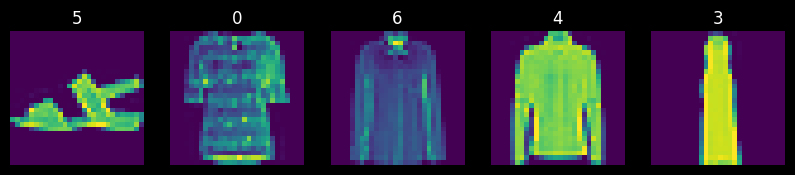

In [74]:
import matplotlib.pyplot as plt

loader = DataLoader(dataset, batch_size=5, shuffle=True)
images, labels = next(iter(loader))

fig, axes = plt.subplots(1, 5, figsize=(10, 2))

for i in range(5):
    axes[i].imshow(images[i].squeeze())
    axes[i].set_title(labels[i].item())
    axes[i].axis("off")

plt.show()

<h3> Transformacje </h3>
Transformacje służą do przygotowania obrazów przed podaniem ich do modelu. <br>


Przykładowe transformacje: <br>
zmiana rozmiaru,
zamiana obrazu na tensor,
normalizacja,
losowe odbicie,
losowe przycięcie obrazu.

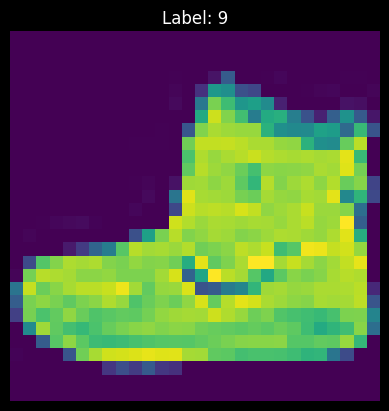

In [75]:
image, label = dataset[0]

plt.imshow(image.squeeze())
plt.title(f"Label: {label}")
plt.axis("off")

In [76]:
from torchvision.transforms import v2

transform = v2.Compose([
    v2.Resize((224, 224)),
    v2.RandomHorizontalFlip(p=1.0),
    v2.RandomRotation(degrees=25),
    v2.ColorJitter(
        brightness=0.5,
        contrast=0.5,
        saturation=0.5
    ),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

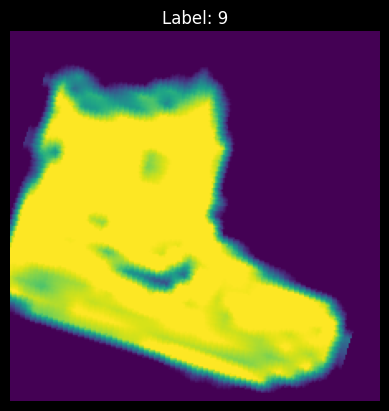

In [77]:
image_transformed = transform(image)

plt.imshow(image_transformed.squeeze())
plt.title(f"Label: {label}")
plt.axis("off")

Inny przykład na innym datasecie

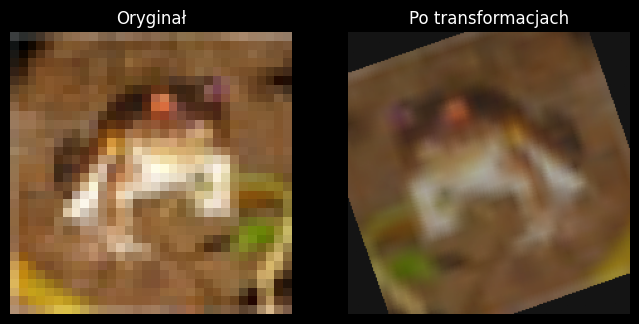

In [78]:
raw_dataset = datasets.CIFAR10(
    root="data",
    train=True,
    download=True
)

image, label = raw_dataset[0]

visible_transform = v2.Compose([
    v2.Resize((224, 224)),
    v2.RandomHorizontalFlip(p=1.0),
    v2.RandomRotation(degrees=25),
    v2.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

transformed_image = visible_transform(image)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(image) # obraz typu PIL Image
axes[0].set_title("Oryginał")
axes[0].axis("off")

axes[1].imshow(transformed_image.permute(1, 2, 0))  # permute bo PyTorch trzyma obrazy jako (C, H, W) a matplotlib chce (H,W,C)
axes[1].set_title("Po transformacjach")
axes[1].axis("off")

plt.show()

<h3> Modele </h3>
torchvision.models zawiera gotowe architektury modeli, często z pretrenowanymi wagami. Znajduje się tam wiele popularnych modeli, m.in: <br>
- ResNet <br>
- VGG <br>
- MobileNet <br>
- EfficientNet <br>
- VisionTransformer (ViT)

https://docs.pytorch.org/vision/main/models.html

In [79]:
from PIL import Image
from torchvision.models import resnet18, ResNet18_Weights
import torch

weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)
model.eval()

preprocess = weights.transforms()

image = Image.open("cat.png").convert("RGB")

x = preprocess(image).unsqueeze(0)

with torch.no_grad():
    output = model(x)

pred = output.argmax(dim=1)
categories = weights.meta["categories"]
print(pred)
print(categories[pred])

tensor([281])
tabby


<h2> Torchaudio </h2>
torchaudio to pakiet PyTorcha do pracy z dźwiękiem. <br>

Pomaga w: <br>

- wczytywaniu plików audio <br>
- przetwarzaniu sygnałów <br>
- tworzeniu reprezentacji (np. spektrogramów) <br>
- przygotowaniu danych pod modele

Waveform = surowy przebieg fali dźwiękowej w czasie. W torchvision ma kształt [kanały, liczba_próbek] <br>
1 kanał = mono, 2 kanały = stereo (ściężke dźwięku prawą i lewą).

Sample rate = liczba próbek dźwięku na sekundę, np. sample_rate = 16000 oznacza, że w każdej sekundzie nagrania zapisano 16000 próbek.


Dla lepszej demonstracji użyjemy wygenerowanego dźwięku

In [80]:
import math
import torch
import torchaudio.functional as F
import matplotlib.pyplot as plt
from IPython.display import Audio
sample_rate = 16_000
note_duration = 0.45

melody = [
    261.63, 293.66, 329.63, 392.00,
    329.63, 293.66, 261.63, 220.00,
    261.63, 329.63, 392.00, 523.25,
    440.00, 392.00, 329.63, 261.63,
]

pieces = []

for freq in melody:
    t_note = torch.linspace(0, note_duration, int(sample_rate * note_duration))

    # podstawowy ton + harmoniczne
    tone = (
        torch.sin(2 * math.pi * freq * t_note)
        + 0.35 * torch.sin(2 * math.pi * 2 * freq * t_note)
        + 0.12 * torch.sin(2 * math.pi * 3 * freq * t_note)
    )


    attack = int(0.04 * sample_rate)
    release = int(0.12 * sample_rate)

    env = torch.ones_like(tone)
    env[:attack] = torch.linspace(0, 1, attack)
    env[-release:] = torch.linspace(1, 0, release)

    pieces.append(0.4 * tone * env)

wave = torch.cat(pieces)
waveform = wave.unsqueeze(0)

waveform = F.lowpass_biquad(
    waveform,
    sample_rate=sample_rate,
    cutoff_freq=3000
)

# echo
delay_samples = int(0.22 * sample_rate)
echo = torch.zeros_like(waveform)
echo[:, delay_samples:] = 0.35 * waveform[:, :-delay_samples]

waveform = waveform + echo
waveform = waveform / waveform.abs().max() * 0.8


Audio(waveform.numpy(), rate=sample_rate)

In [81]:
print("Waveform shape:", waveform.shape)
print("Sample rate:", sample_rate)

Waveform shape: torch.Size([1, 115200])
Sample rate: 16000


Wizualizacja surowej fali audio

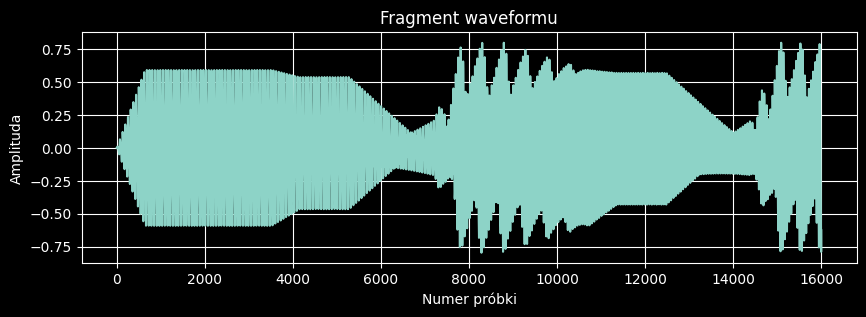

In [82]:
plt.figure(figsize=(10, 3))
plt.plot(waveform[0][:16000].numpy())
plt.title("Fragment waveformu")
plt.xlabel("Numer próbki")
plt.ylabel("Amplituda")
plt.grid(True)
plt.show()

<h3> Resampling - zmiana częstotliwości próbkowania </h3>

Resampling jest bardzo ważny, ponieważ modele audio często wymagają konkrentego sample rate, na przykład 4 kHz

In [83]:
import torchaudio
import matplotlib.pyplot as plt
import torchaudio.functional as F
import torchaudio.transforms as T
target_sr = 4_000

resampler = T.Resample(orig_freq=sample_rate, new_freq=target_sr)
waveform_4k = resampler(waveform)

Audio(waveform_4k.numpy(), rate=target_sr)

In [84]:
print("oryginal:", waveform.shape, sample_rate)
print("resampled:", waveform_4k.shape, target_sr)

oryginal: torch.Size([1, 115200]) 16000
resampled: torch.Size([1, 28800]) 4000


<h3> Spektrogramy </h3>
obraz pokazujący, jakie częstotliwości występują w dźwięku w czasie


niższy sample rate = mniejszy zakres częstotliwości <br>
wyższy sample rate = więcej informacji, ale <b>większy koszt</b>

In [85]:
def show_spectrogram(waveform, sample_rate, n_fft=1024, hop_length=256):
    spectrogram_transform = torchaudio.transforms.Spectrogram(
        n_fft=n_fft,
        hop_length=hop_length,
        power=2
    )

    spectrogram = spectrogram_transform(waveform)

    # zamiana na skalę decybelową
    spectrogram_db = torchaudio.transforms.AmplitudeToDB()(spectrogram)


    num_frames = spectrogram_db.shape[-1]

    time_max = num_frames * hop_length / sample_rate
    freq_max = sample_rate / 2

    plt.figure(figsize=(10, 4))
    plt.imshow(
        spectrogram_db[0].numpy(),
        aspect="auto",
        origin="lower",
        extent=[0, time_max, 0, freq_max]
    )

    plt.title(f"Spektrogram, sample_rate = {sample_rate}")
    plt.xlabel("Czas [s]")
    plt.ylabel("Częstotliwość [Hz]")
    plt.colorbar(label="dB")
    plt.show()

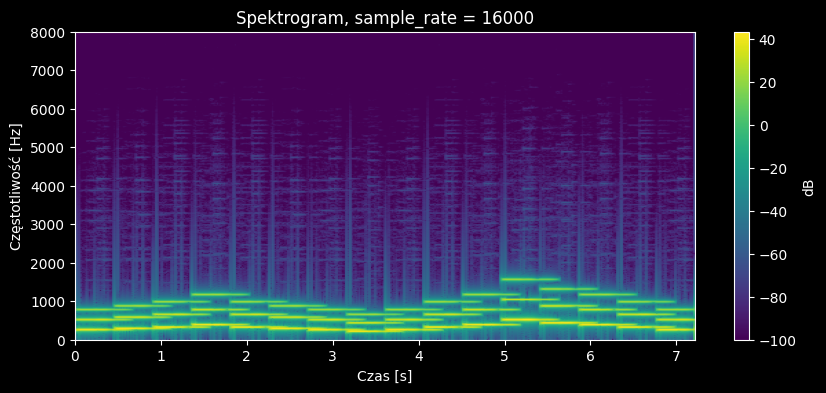

In [86]:
show_spectrogram(waveform, sample_rate=16000)

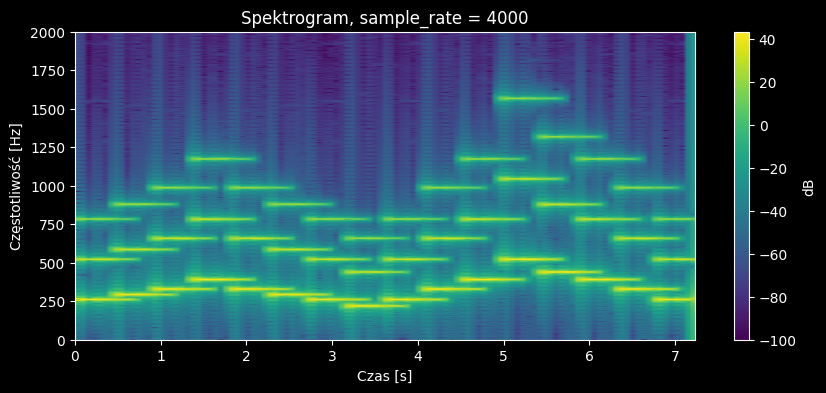

In [87]:
show_spectrogram(waveform_4k, sample_rate=4000)

<h2> Mel-spektrogram </h2>
oś częstotliwości (ze spektrogramu) jest tak przeskalowana, żeby bardziej przypominała sposób, w jaki słszy człowek.

Jest bardzo popularny w uczeniu maszynowym - zamienia audio na reprezentację podobną do obrazu i dobrze pokazuje cechy ważne np. dla mowy lub klasyfikacji dźwięków.

In [88]:
def show_mel(wav, sr, title):
    mel = T.MelSpectrogram(
        sample_rate=sr,
        n_fft=1024,
        hop_length=256,
        n_mels=64
    )(wav)

    mel_db = T.AmplitudeToDB()(mel)

    plt.figure(figsize=(10, 4))
    plt.imshow(mel_db[0], origin="lower", aspect="auto")
    plt.title(title)
    plt.xlabel("Ramki czasu")
    plt.ylabel("Pasma Mel")
    plt.colorbar()
    plt.show()

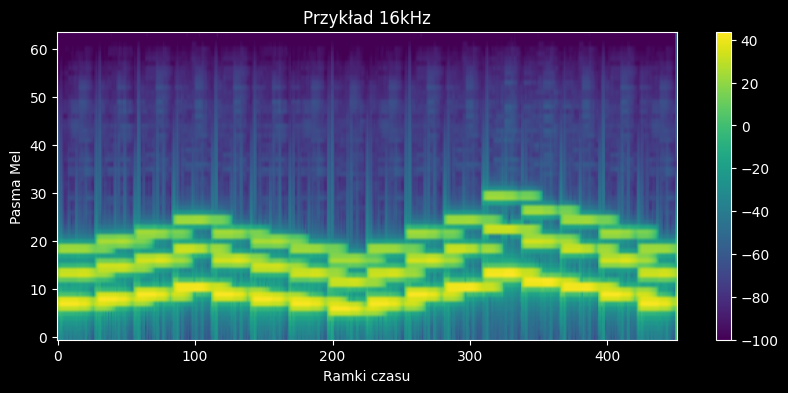

In [89]:
show_mel(waveform, 16_000, "Przykład 16kHz")

<h3> Działania na dźwięku </h3>

Możemy na przykład dodać losowy szum

In [90]:
noise_level = 0.05

# losowy szum o takim samym kształcie jak waveform
noise = noise_level * torch.randn_like(waveform)

noisy_waveform = waveform + noise

# normalizacja, żeby nie było przesterowania
noisy_waveform = noisy_waveform / noisy_waveform.abs().max() * 0.8

display(Audio(noisy_waveform.numpy(), rate=sample_rate))